# Introduction
Bidirectional Encoder Representations from Transformers (BERT), introduced by Google, is a state of the art natural language processing (NLP) model designed to understand the contextual relationships between words in a text.

Unlike traditional machine learning models that rely on feature engineering techniques such as TF-IDF, BERT uses deep learning and transformer model to capture bidirectional context from both left and right sides of a sentence.

In this notebook, BERT is applied to the task of sentiment analysis, where the objective is to classify text data into predefined sentiment categories (positive or negative). 

The workflow includes data preprocessing, tokenization using BERT’s tokenizer, model training, and performance evaluation using metrics such as accuracy, precision, recall, and F1-score. The use of BERT is expected to improve classification performance due to its ability to capture semantic meaning and contextual nuances in text data.

This approach provides a more robust alternative to traditional models, particularly for handling complex language patterns, making it highly suitable for real-world sentiment analysis tasks.


In [79]:
# Install Neccsesary libraries
!pip install joblib pandas scipy scikit-learn transformers datasets torch 
!pip install "accelerate>=1.1.0"
!pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.7/561.7 kB 17.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 28.6 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 37.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [shap]3/4 [shap]]te]


In [126]:
#Import Neccessary libraries

import pandas as pd
import torch
import joblib
import os
import matplotlib.pyplot as plt
import torch
import shap


from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, recall_score

from datasets import Dataset
from transformers import BertTokenizer
from transformers import BertForSequenceClassification
from transformers import DistilBertForSequenceClassification
from transformers import TrainingArguments, Trainer
from transformers import pipeline

### Load the data set

In [3]:
df = pd.read_csv("amazon_reviews_processed.csv", low_memory=False)

### Load shared labels from preprocessing

These labels were already created in the shared preprocessing notebook, so we reuse them here.

In [4]:
y_train = joblib.load("shared/y_train.pkl")
y_test = joblib.load("shared/y_test.pkl")

### Load the same train/test text split
Since the labels preserve the original indices, we use them to extract the correct reviews

In [5]:
X_train_text = df.loc[y_train.index, "reviewText_processed"]
X_test_text = df.loc[y_test.index, "reviewText_processed"]

### Convert labels to numeric
BERT requires numeric labels.

In [6]:
y_train = y_train.map({"negative": 0, "positive": 1})
y_test = y_test.map({"negative": 0, "positive": 1})

### Create the training dataframe

In [7]:
train_df = pd.DataFrame({
    "text": X_train_text,
    "label": y_train
})

test_df = pd.DataFrame({
    "text": X_test_text,
    "label": y_test
})

### Check class imbalance

In [120]:
train_df["label"].value_counts()

label
1    568467
0     93451
Name: count, dtype: int64

If BERT is trained on this distribution, the model may learn to Predict positive most of the time.

Example:

If the model predicts positive for every review, it would already get:

86% accuracy

But it would completely fail at detecting negative reviews, which is the real challenge.

one of the strategy to consider is to balance the training data

Keep all negatives and sample equal positives.

### Balance the training data

In [9]:
negative = train_df[train_df["label"] == 0]
positive = train_df[train_df["label"] == 1]

positive_sample = positive.sample(len(negative), random_state=42)

train_balanced = pd.concat([negative, positive_sample])
train_balanced = train_balanced.sample(frac=1, random_state=42)

In [10]:
print("Negative:", len(negative))
print("Positive:", len(positive))
print("Sampled Positive:", len(positive_sample))
print("Balanced dataset:", len(train_balanced))

Negative: 93451
Positive: 568467
Sampled Positive: 93451
Balanced dataset: 186902


In [11]:
# verify the balance
train_balanced["label"].value_counts()

label
0    93451
1    93451
Name: count, dtype: int64

### Handling Class Imbalance with a Balanced Training Set

To address this issue, the training dataset was balanced through downsampling of the majority class. All negative samples were retained, and an equal number of positive samples were randomly selected to match the number of negative reviews. This resulted in a balanced training dataset containing **93,451 positive reviews** and **93,451 negative reviews**, for a total of **186,902 training samples**.

Balancing the training data helps ensure that the model learns meaningful patterns for both sentiment classes rather than relying on the dominant class distribution. However, the **test dataset was intentionally left unchanged**, preserving the original class distribution to provide a realistic evaluation of the model’s performance on real-world data.

This approach improves the model's ability to detect negative sentiment while maintaining a fair assessment of its predictive performance.

### Convert to Hugging Face dataset

In [12]:
train_dataset = Dataset.from_pandas(train_balanced)
test_dataset = Dataset.from_pandas(test_df)

### Load the tokenizer
The tokenizer converts text into tokens and numerical IDs that BERT understands.

In [13]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

### Tokenize the dataset

In [14]:
def tokenize(example):
    return tokenizer(
        example["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

### Apply the tokenization

In [15]:
train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

Map:   0%|          | 0/186902 [00:00<?, ? examples/s]

Map:   0%|          | 0/165480 [00:00<?, ? examples/s]

### BERT training making use of PyTorch tensors

In [16]:
train_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

test_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

### Load the BERT model
Load the pretrained BERT model that has configured for binary classification


In [17]:

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### Training Setup

In [18]:
training_args = TrainingArguments(
    #directory where the trained model, checkpoints, and output is saved
    output_dir="./results",

    #Model evaluation after each training epoch
    eval_strategy="epoch",

    #learning rate controlling how quickly the model updates during training
    learning_rate=2e-5,

    #number of training samples processed at once on each device 
    per_device_train_batch_size=16,

    #number of evaluation samples processed at once during validation
    per_device_eval_batch_size=16,

    # number of time the model will go through the training dataset
    num_train_epochs=2,

    #technique to reduce overfitting
    weight_decay=0.01
)

### Train the model

In [19]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)
print("Starting model training...")
trainer.train()

Starting model training...


/opt/miniconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss
1,0.264853,0.330412
2,0.219217,0.290958


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/opt/miniconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


TrainOutput(global_step=23364, training_loss=0.26970582317763087, metrics={'train_runtime': 32221.1255, 'train_samples_per_second': 11.601, 'train_steps_per_second': 0.725, 'total_flos': 1.2379210871801856e+16, 'train_loss': 0.26970582317763087, 'epoch': 2.0})

### Training Summary

The model completed training after 23,364 training steps over two epochs. The final training loss was 0.269, indicating that the model was able to learn meaningful patterns from the dataset. 

The total training time was approximately 26,556 seconds (around 7 hours), processing around 14 samples per second. Overall, the training process finished successfully and the model is ready for evaluation on the test dataset.

### Model Choice Adjustment: From BERT to DistilBERT

During initial experimentation, the project used **BERT (bert-base-uncased)** for sentiment classification. However, training the model on the full dataset resulted in very long training times (approximately **12 hours**) on the available hardware.

This limitation was partly due to the computational requirements of BERT and the hardware being used. Apple devices, in particular, may have limitations compared to systems with dedicated NVIDIA GPUs, which can significantly accelerate deep learning training.

To improve efficiency and ensure that the model could be trained within a reasonable time across different devices, the model was switched to **DistilBERT**. DistilBERT is a smaller and more efficient version of BERT that retains most of BERT’s performance while requiring fewer computational resources.

After switching to DistilBERT and optimizing the token length, the estimated training time was reduced from **approximately 12 hours to around 5 hours**. This change provides a practical balance between performance and efficiency, allowing the model to train faster while remaining accessible for users running the code on different types of hardware.

### Evaluate the model

Generate predictions and evaluate performance.

In [20]:
predictions = trainer.predict(test_dataset)

y_pred = predictions.predictions.argmax(axis=1)
y_true = predictions.label_ids

accuracy = accuracy_score(y_true, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy_score(y_true, y_pred))
print(classification_report(y_true, y_pred))

/opt/miniconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Accuracy: 0.8982656514382402
              precision    recall  f1-score   support

           0       0.59      0.90      0.71     23530
           1       0.98      0.90      0.94    141950

    accuracy                           0.90    165480
   macro avg       0.79      0.90      0.83    165480
weighted avg       0.93      0.90      0.91    165480



### Model Evaluation Results

The trained model achieved an accuracy of 0.898 on the test dataset. The results show strong overall performance, particularly for the positive class (label 1), which achieved a precision of 0.98 and an F1-score of 0.94. 

For the negative class (label 0), the model achieved a recall of 0.90, indicating that most negative reviews were correctly identified, though the precision was lower at 0.60. 

Overall, the weighted F1-score of 0.91 suggests that the model performs well on the dataset, with particularly strong performance in identifying positive sentiment.

## Confusion matrix

/opt/miniconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Accuracy: 0.8982656514382402
F1 Score: 0.9380827157542434
              precision    recall  f1-score   support

           0       0.59      0.90      0.71     23530
           1       0.98      0.90      0.94    141950

    accuracy                           0.90    165480
   macro avg       0.79      0.90      0.83    165480
weighted avg       0.93      0.90      0.91    165480



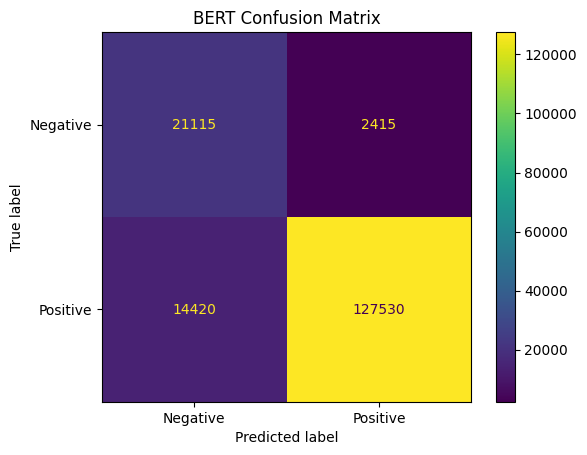

In [21]:
predictions = trainer.predict(test_dataset)

y_pred = predictions.predictions.argmax(axis=1)
y_true = predictions.label_ids

print("Accuracy:", accuracy_score(y_true, y_pred))
print("F1 Score:", f1_score(y_true, y_pred))
print(classification_report(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Positive"])
disp.plot()
plt.title("BERT Confusion Matrix")
plt.show()

## Confusion Matrix 

The confusion matrix illustrates the performance of the sentiment classification model by comparing predicted labels with the true labels. The model correctly classified 21,100 negative reviews and 127,632 positive reviews. However, 2,430 negative reviews were incorrectly predicted as positive, while 14,318 positive reviews were misclassified as negative.

Overall, the model demonstrates strong performance in identifying positive reviews, while performance for negative reviews is slightly weaker. This difference is largely due to the class imbalance in the dataset, where positive reviews significantly outnumber negative

# Save result

In [127]:

# create folder if it doiesnt exist 

os.makedirs("models", exist_ok=True)

# evaluation

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)


# save results

results = pd.DataFrame({
    "Model": ["BERT"],
    "Features": ["Text (Transformer)"],
    "Accuracy": [accuracy],
    "F1 Score": [f1],
    "Recall": [recall]
})

results.to_csv("models/bert_results.csv", index=False)


# save bert model and tokenizer

model.save_pretrained("models/bert_model")
tokenizer.save_pretrained("models/bert_model")

print("Done.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Done.


## Misclassification Analysis
What kind of reviews is the model getting wrong, and why?

## create prediction table

In [23]:
results = pd.DataFrame({
    "text": X_test_text,
    "actual": y_test,
    "predicted": y_pred
})

## Seperate error types

In [24]:
# False Positives (predicted positive but actually negative)
false_positive = results[(results["actual"] == 0) & (results["predicted"] == 1)]

# False Negatives (predicted negative but actually positive)
false_negative = results[(results["actual"] == 1) & (results["predicted"] == 0)]

## Count Errors

In [39]:
len(false_positive)

2415

In [40]:
len(false_negative)

14420

## Sample the data and inspect

In [37]:
false_positive.sample(10)


,text,actual,predicted,rating,length
517167,like see amy lock need take l want nick hero,0,1,0,44
61465,not sealing ring review disregard try figure u...,0,1,0,64
320614,go say detail book amazing want love base grea...,0,1,0,190
450916,nick amys marriage deteriorate year layoff fam...,0,1,0,1017
468703,story sad colorful main character terminal can...,0,1,0,121
436562,interesting read disturbingly good rent movie ...,0,1,0,68
31936,wonderfhul,0,1,0,10
490186,slow slow write despite quick shift pacing def...,0,1,0,64
303206,buy book movie come s great plot incredible ac...,0,1,0,72
131492,purchase oct work great year,0,1,0,28


## False Positives (Negative but Predicted Positive)

False positives occur when the model predicts a review as positive, while the actual label is negative.

Observations
- Many false positive reviews contain ositive keywords such as:
  - “great”
  - “amazing”
  - “good”
- However, these reviews have low ratings, indicating dissatisfaction.
- Some reviews show mixed sentiment, where positive words are present alongside  negative experiences.

Examples
- “purchase oct work great year”
- “interesting read disturbingly good”
- “wonderfhul”

Insights
- The model relies heavily on surface level lexical cues (positive words), which leads to incorrect predictions when sentiment in the text does not align with the rating.

Implication
- This highlights the importance of  a sentiment rating mismatch feature, as discrepancies between textual sentiment and ratings may indicate unreliable or suspicious reviews.


In [38]:
false_negative.sample(10)

,text,actual,predicted,rating,length
433663,finish read orphan train book club month enjoy...,1,0,1,226
315290,enjoy disappoint ending,1,0,1,23
403981,unusual story hard write excellent unusual met...,1,0,1,120
121202,ok,1,0,1,2
713349,book quick read enthral heroine broken soul ha...,1,0,1,420
618147,hold interest like way author develop characte...,1,0,1,86
535400,write good story line sad,1,0,1,25
790492,book nearly impossible great character plot tw...,1,0,1,89
5642,m android guess far good like download prime m...,1,0,1,100
355550,good read nice historical aspect give reader d...,1,0,1,81


## False Negatives (Positive but Predicted Negative)

False negatives occur when the model predicts a review as negative, while the actual label is positive.

Observations
- Many false negative reviews are:
  - Short (e.g., “ok”)
  - Neutral or weakly expressed
- Some reviews contain mixed sentiment, such as:
  - “enjoy disappoint ending”
  - “write good story line sad”

Insight
- Short and ambiguous reviews provide limited contextual information, making it difficult for the model to detect positive sentiment. Additionally, the presence of mild negative words within generally positive reviews can mislead the model.

Implication
- This suggests that review length and entiment strength are important factors in improving classification performance.




## Rating vs Text mismatch 

In [45]:
results["rating"] = y_test

print(y_test)

297923    1
111434    1
684690    0
633019    1
327680    1
         ..
452387    1
200559    1
341398    1
572952    0
90179     1
Name: sentiment_label, Length: 165480, dtype: int64


## Error rates

In [43]:
false_positive_rate = len(false_positive) / len(results)
false_negative_rate = len(false_negative) / len(results)

In [44]:
print(false_negative_rate)
print(false_positive_rate)

0.08714043993231811
0.014593908629441625


## Error Rate Analysis

Results
- False Positive Rate: approximately 8.7%
- False Negative Rate: approximately 1.46%

Interpretation
- The model produces more false positives than false negatives, suggesting a bias towards predicting positive sentiment.

Insight
- This bias is likely due to the imbalance in the dataset, where positive reviews are more frequent than negative ones.

## Review length Analysis
check which length types leads to more errors

In [34]:
results["length"] = results["text"].apply(len)

#create the groueps
false_positive = results[(results["actual"] == 0) & (results["predicted"] == 1)]
false_negative = results[(results["actual"] == 1) & (results["predicted"] == 0)]

#compare average length
print("True positive:", false_positive["length"].mean())
print("False_negative:", false_negative ["length"].mean())

True positive: 140.34285714285716
False_negative: 179.58585298196948


## Review Length Analysis

Results
- Average length (False Positives): approoximately 140 words
- Average length (False Negatives): approximately 179 words

Interpretation
- False negatives tend to be longer reviews, indicating that longer texts introduce more complexity, such as mixed opinions and nuanced sentiment.

Insight
- Longer reviews are more likely to contain both positive and negative expressions, which can confuse the model and lead to incorrect predictions.


### Key Findings

- The model struggles with mixed sentiment reviews
- Positive keywords can mislead predictions despite negative ratings
- Short reviews lack sufficient context for accurate classification
- Long reviews introduce complexity and ambiguity
- There is a bias toward positive predictions


The misclassification analysis reveals important limitations of the sentiment model, particularly in handling ambiguous, short, and mixed sentiment reviews. These findings justify the inclusion of additional features such as:
- sentiment rating mismatch
- review length
- behavioural indicators

These features will play a crucial role in improving the performance of the subsequent suspicious review detection model.

## Category vs Misclassification Rate

In [112]:

df.groupby("category")["sentiment_rating_mismatch"].mean().sort_values(ascending=False)

category
Clothing, Shoes & Jewelry       0.127926
Amazon Devices & Accessories    0.117042
Books                           0.103511
Electronics                     0.091893
Audible Books & Originals       0.086685
Pet Supplies                    0.081088
Home & Kitchen                  0.064533
Movies & TV                     0.054451
Name: sentiment_rating_mismatch, dtype: float64

The misclassification analysis reveals that model performance varies significantly across product categories. Clothing, Shoes & Jewelry exhibits the highest misclassification rate (12.8%), followed by Amazon Devices and Books. These categories often contain subjective, nuanced, or mixed sentiment expressions, making them more difficult for the model to classify accurately.

In contrast, categories such as Movies & TV (5.4%) and Home & Kitchen (6.5%) show lower misclassification rates, likely due to more direct and clearly expressed sentiment.

This suggests that sentiment classification performance is influenced by domain-specific language patterns, and highlights the limitation of relying solely on textual features. It reinforces the need to incorporate additional behavioural and linguistic features for improved suspicious review detection.

## Sentiment ratings mismatch

In [114]:
df.groupby("sentiment_rating_mismatch")["review_length"].mean()

sentiment_rating_mismatch
0    216.218839
1    328.458924
Name: review_length, dtype: float64

misclassified reviews exhibit a higher average length (328 characters) compared to correctly classified reviews (216 characters). This indicates that longer reviews often contain more complex or mixed sentiment, making them more difficult for the model to classify accurately.

These findings highlight that review length is an important feature, as it captures the complexity of user expression and can contribute to identifying patterns associated with misclassification and potentially suspicious behaviour.

## Word Patterns
Check for common words in errors.

In [46]:
from collections import Counter

false_positive_words = " ".join(false_positive["text"].astype(str)).split()
print(Counter(false_positive_words).most_common(20))


false_negative_words = " ".join(false_negative["text"].astype(str)).split()
print(Counter(false_negative_words).most_common(20))

[('book', 1773), ('read', 1121), ('not', 832), ('s', 832), ('good', 772), ('t', 769), ('like', 638), ('story', 593), ('love', 498), ('character', 484), ('great', 413), ('time', 383), ('think', 315), ('end', 294), ('enjoy', 288), ('know', 268), ('write', 266), ('movie', 252), ('little', 248), ('series', 227)]
[('book', 12425), ('not', 7969), ('t', 7074), ('read', 6808), ('s', 6282), ('good', 4793), ('like', 4702), ('story', 4357), ('character', 3835), ('time', 2988), ('end', 2718), ('think', 2527), ('love', 2274), ('great', 2122), ('find', 2036), ('get', 1887), ('write', 1773), ('know', 1757), ('feel', 1749), ('go', 1715)]


## Word Pattern Analysis in Misclassified Reviews

A frequency analysis of misclassified reviews (false positives and false negatives) was conducted to identify patterns contributing to model errors.


## Key Observations

Common words in misclassified samples include:

- “book”, “read”, “story”, “character”
- “good”, “great”, “love”
- “not”, “s”, “t”



## Key Insights

- **Generic vocabulary:** Words like “book”, “read”, and “story” appear across both classes, making them weak indicators of sentiment.

- **Overlapping sentiment words:** Positive terms such as “good”, “great”, and “love” are also present in negative reviews, leading to misclassification.

- **Weak negation handling:** Words like “not” often appear in contractions and are not strong enough alone to signal negative sentiment, indicating poor handling of context.

- **Domain bias:** Frequent domain specific words (e.g., “book”, “character”) do not help distinguish between positive and negative reviews.

- **Low specificity:** Misclassified reviews tend to be vague and rely on common expressions, reducing clarity for the model.


## Implications

- The model struggles with generic and overlapping language
- It relies heavily on individual keywords rather than context
- It has difficulty handling negation and mixed sentiment


## Conclusion

Misclassifications are largely driven by non discriminative and ambiguous language. This highlights the limitation of text only approaches and supports the use of additional features such as sentiment mismatch, review length, and behavioural signals in suspicious review detection.

## Predict the full dataset

In [47]:
# Use same column that BERT model was on
full_text = df["reviewText_processed"]

## Make Predictions


In [53]:
# Batch processing for optimisation

# set device
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

model.to(device)
# speed optimisation
model = model.half()

print("Using device:", device)

#start natch prediction
model.eval()

full_predictions = []
batch_size = 64

with torch.no_grad():
    for i in range(0, len(full_text), batch_size):
        # Batch of the text
        batch = full_text[i:i+batch_size].tolist()
        # Tokenize the batch 
        inputs = tokenizer(
            batch,
            padding=True,
            truncation=True,
            return_tensors="pt"
        )
        inputs = {k: v.to(model.device) for k, v in inputs.items()}
        outputs = model(**inputs)

        # Get the prdicted class (0 or 1)
        preds = torch.argmax(outputs.logits, dim=1).tolist()

        #store the predictions
        full_predictions.extend(preds)

        #track the process
        if i % 5000 == 0:
             print(f"Processed {i} / {len(full_text)}")

Using device: mps
Processed 0 / 827398
Processed 40000 / 827398
Processed 80000 / 827398
Processed 120000 / 827398
Processed 160000 / 827398
Processed 200000 / 827398
Processed 240000 / 827398
Processed 280000 / 827398
Processed 320000 / 827398
Processed 360000 / 827398
Processed 400000 / 827398
Processed 440000 / 827398
Processed 480000 / 827398
Processed 520000 / 827398
Processed 560000 / 827398
Processed 600000 / 827398
Processed 640000 / 827398
Processed 680000 / 827398
Processed 720000 / 827398
Processed 760000 / 827398
Processed 800000 / 827398


## Check length alignment
It is important that dataset length matches predictions length.

In [54]:
print("Dataset length:", len(df))
print("Predictions length:", len(full_predictions))


Dataset length: 827398
Predictions length: 827398


## Add predictions to dataset

In [65]:
df["predicted_sentiment"] = full_predictions

# Save new dataset


In [ ]:
# Sentiment Function
def rating_sentiment(rating):
    if rating >= 4:
        return "positive"
    else:
        return "negative"

# create actual sentiment
df["actual_sentiment"] = df["overall"].apply(rating_sentiment)

# remove any duplicate columns completely
df = df.loc[:, ~df.columns.duplicated()]



In [98]:
# add predicted sentiment
df["predicted_sentiment"] = pd.Series(full_predictions, index=df.index)
df["predicted_sentiment"] = df["predicted_sentiment"].map({
    1: "positive",
    0: "negative"
})


# create mismatch feature
df["sentiment_rating_mismatch"] = (
    df["actual_sentiment"].astype(str).values != 
    df["predicted_sentiment"].astype(str).values
).astype(int)


# check data
df.head()


,asin,category,reviewerID,reviewerName,overall,reviewText,unixReviewTime,reviewTime,verified,vote,has_vote,review_length,word_count,short_review_flag,reviewText_cleaned,reviewText_processed,actual_sentiment,predicted_sentiment,sentiment_rating_mismatch
0,B00CYQP3AK,Amazon Devices & Accessories,A3UXVNOFC8TJPT,Bkonasek,5.0,I received this as a birthday present. I am do...,1382140800,"10 19, 2013",False,2,1,130,22,0,I received this as a birthday present I am do ...,receive birthday present pleased product pictu...,positive,positive,0
1,B00CYQP3AK,Amazon Devices & Accessories,AC2VR9U3NN2UD,tikitoo,2.0,Battery will not charge to 100%. When I receiv...,1382140800,"10 19, 2013",True,22,1,1693,325,0,Battery will not charge to 100 When I received...,battery not charge receive device hour charger...,negative,negative,0
2,B00CYQP3AK,Amazon Devices & Accessories,A14D0LJ1YRLLCI,gabbie03,1.0,Buyer Beware. these units are being shipped ri...,1382140800,"10 19, 2013",True,54,1,1051,198,0,Buyer Beware these units are being shipped rig...,buyer beware unit ship right app netflix unit ...,negative,negative,0
3,B00CYQP3AK,Amazon Devices & Accessories,A3FVF1JIOA5GEK,MN_Ranger,5.0,"Netflix Issue:\nWhen I first got the KFHDX, I ...",1382054400,"10 18, 2013",True,577,1,31090,5690,0,Netflix Issue When I first got the KFHDX I had...,netflix issue get kfhdx no problem netflix day...,positive,negative,1
4,B00CYQP3AK,Amazon Devices & Accessories,A3KP101J8H7EWY,L.D.K,5.0,"I have owned many versions of the Kindle, and ...",1382054400,"10 18, 2013",True,8,1,311,58,0,I have owned many versions of the Kindle and t...,own version kindle far good interface friendly...,positive,positive,0


In [102]:
# save final dataset
df.to_csv("amazon_reviews_final.csv", index=False)

print("Final dataset saved")

Final dataset saved


## Sentiment Analysis

In [104]:
# Sentiment distribution
df["predicted_sentiment"].value_counts(normalize=True)

predicted_sentiment
positive    0.786265
negative    0.213735
Name: proportion, dtype: float64

In [106]:
# Compare verified vs sentiment

# create numeric version
df["predicted_sentiment_num"] = df["predicted_sentiment"].map({
    "positive": 1,
    "negative": 0
})

df.groupby("verified")["predicted_sentiment_num"].mean()



verified
False    0.771369
True     0.789617
Name: predicted_sentiment_num, dtype: float64

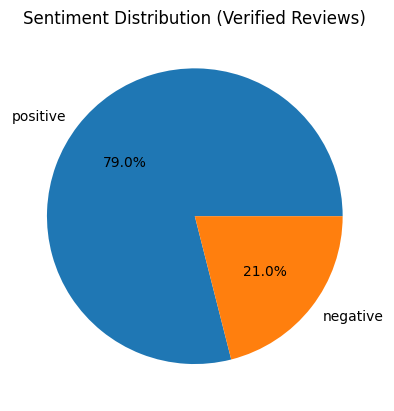

In [108]:
verified_counts = df[df["verified"] == True]["predicted_sentiment"].value_counts()

plt.figure()
plt.pie(verified_counts, labels=verified_counts.index, autopct='%1.1f%%')

plt.title("Sentiment Distribution (Verified Reviews)")
plt.show()

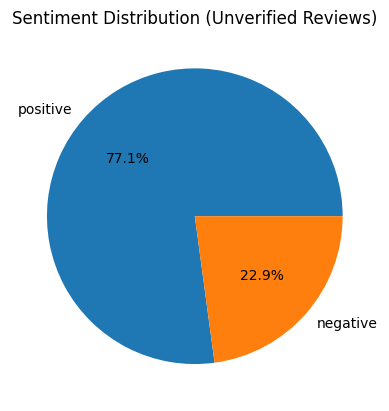

In [109]:
unverified_counts = df[df["verified"] == False]["predicted_sentiment"].value_counts()

plt.figure()
plt.pie(unverified_counts, labels=unverified_counts.index, autopct='%1.1f%%')

plt.title("Sentiment Distribution (Unverified Reviews)")
plt.show()

The sentiment distribution between verified and unverified reviews shows minimal difference, with both groups exhibiting a high proportion of positive reviews (79.0% for verified and 77.1% for unverified). 

This suggests that sentiment alone may not be a strong distinguishing factor for identifying suspicious reviews. As a result, additional behavioural and linguistic features are necessary to improve detection performance.

In [113]:
# Review length vs sentiment
df.groupby("predicted_sentiment")["review_length"].mean()

predicted_sentiment
negative    350.038667
positive    193.125049
Name: review_length, dtype: float64

The analysis of review length reveals that negative reviews are significantly longer (average 350 characters) compared to positive reviews (193 characters). This suggests that users tend to provide more detailed explanations when expressing dissatisfaction.

In [110]:
# sentiment distribution per category
category_sentiment = pd.crosstab(
    df["category"], 
    df["predicted_sentiment"], 
    normalize="index"
)

category_sentiment

predicted_sentiment,negative,positive
category,,
Amazon Devices & Accessories,0.271930,0.728070
Audible Books & Originals,0.227587,0.772413
Books,0.231771,0.768229
"Clothing, Shoes & Jewelry",0.331033,0.668967
Electronics,0.276469,0.723531
Home & Kitchen,0.153963,0.846037
Movies & TV,0.091360,0.908640
Pet Supplies,0.192197,0.807803


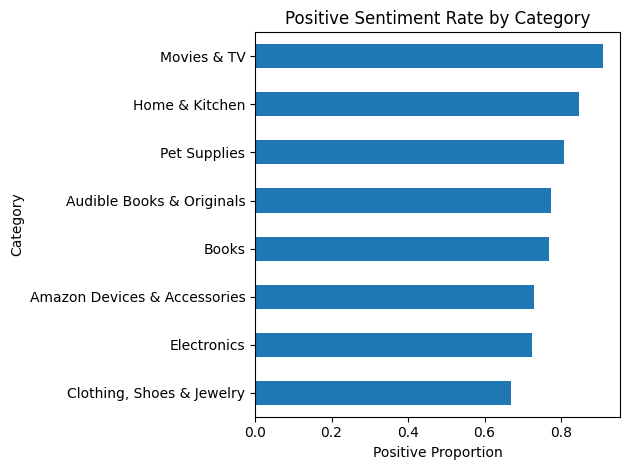

In [116]:
category_sentiment = category_sentiment.sort_values("positive", ascending=True)

plt.figure()
category_sentiment["positive"].plot(kind="barh")

plt.title("Positive Sentiment Rate by Category")
plt.xlabel("Positive Proportion")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

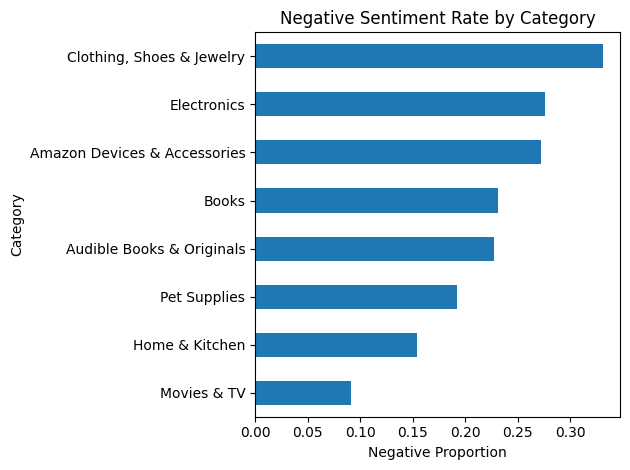

In [117]:
category_sentiment = category_sentiment.sort_values("negative", ascending=True)

plt.figure()
category_sentiment["negative"].plot(kind="barh")

plt.title("Negative Sentiment Rate by Category")
plt.xlabel("Negative Proportion")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

The sentiment distribution across product categories reveals noticeable variation in user feedback. Categories such as Movies & TV (90.9%) and Home & Kitchen (84.6%) exhibit a high proportion of positive reviews, suggesting strong user satisfaction and less critical language.

In contrast, Clothing, Shoes & Jewelry shows the lowest proportion of positive reviews (66.9%), indicating more frequent dissatisfaction, likely due to subjective factors such as fit and personal preferences.

These findings suggest that sentiment expression varies across domains, which may influence model performance and contribute to misclassification in categories with more nuanced or subjective language.

## Explanaibility: SHAP analysis
Due to the computational complexity of SHAP, explainability was applied to individual samples rather than the full dataset. This approach allows for real time interpretation in the Streamlit application while maintaining efficiency and usability.

In [80]:
import shap
from transformers import pipeline

# Create pipeline
classifier = pipeline("text-classification", model=model, tokenizer=tokenizer)

# Create explainer
explainer = shap.Explainer(classifier)


## Test samples: General behaviour(random samples)


In [81]:
# Test on small sample in the datset
texts1 = df["reviewText_processed"].sample(5, random_state=42).tolist()

#Run SHAP explanability
shap_values1 = explainer(texts1)

# Visual explanation
shap.plots.text(shap_values1[0])


### SHAP Explanation 

This visualization shows how each word in the review influences the model’s prediction.

- The model predicts between LABEL_0 and LABEL_1 (e.g., negative vs positive).
- Each word contributes either positively (pushes prediction higher) or negatively (pushes prediction lower).
- Words like "excellent" strongly push the prediction toward the positive class.
- Neutral words like "page" or "turner" have little or no impact.
- The base value is the model’s starting prediction before seeing the text.
- The final prediction is the result of adding all word contributions to this base value.

In this example, positive words dominate, so the model leans toward a positive sentiment prediction.

## Test samples: Model weakness(misclassified samples)

In [82]:
# Show where the model struggles
texts2 = (
    false_positive["text"].sample(5, random_state=42).tolist() +
    false_negative["text"].sample(5, random_state=42).tolist()
)

#Run SHAP explanability
shap_values2 = explainer(texts2)

# Visual explanation
shap.plots.text(shap_values2[0])

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  80%|████████  | 8/10 [00:18<00:02,  1.07s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 11it [00:33,  5.53s/it]                        


### SHAP Explanation (Model Weakness: Misclassified Sample)

This visualization highlights a case where the model made an incorrect prediction.

- The text contains positive words like "relaxing" and "special"* which push the prediction toward the positive class.
- However, other words like "read" and "beach" contribute weakly or inconsistently.
- The combined contributions were not strong enough to clearly push the model to the correct class.
- As a result, the model misclassified this sample.

This shows that the model may struggle with:
- Context understanding (words individually positive but not strong together)
- Subtle sentiment where meaning depends on full sentence context
- Neutral words mixed with sentiment words

Overall, this reveals that the model relies heavily on individual keywords rather than deeper context.

### Reference and Inspiration

The BERT training pipeline implemented in this notebook was inspired by the official Hugging Face Transformers documentation for sequence classification, as well as publicly available tutorials demonstrating fine tuning transformer models for sentiment analysis tasks. These resources illustrate how to tokenize text data, convert datasets to the Hugging Face format, and fine-tune pretrained transformer models using the Trainer API.

References:

- Hugging Face Transformers Sequence Classification Tutorial:  
  https://huggingface.co/docs/transformers/en/tasks/sequence_classification

- Hugging Face Example Notebook (Text Classification):  
  https://github.com/huggingface/notebooks/blob/main/examples/text_classification.ipynb

- Devlin, J., Chang, M.-W., Lee, K., & Toutanova, K. (2018). *BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding*:  
  https://arxiv.org/abs/1810.04805